In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve, auc, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, f1_score, 
                             balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score)
import warnings
warnings.filterwarnings('ignore')

from integrate_vae_synthetic_data import SyntheticDataIntegrator

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

print("=" * 80)
print("Fraud Detection Model: Real vs. Real + Synthetic Data Comparison")
print("=" * 80)


Fraud Detection Model: Real vs. Real + Synthetic Data Comparison


In [29]:
class applyModel():
  def __init__(self, eval=True):
    """
    Initialize class
    Parameters:
    -eval: if model evaluation should be shown
    """
    self.eval = eval

  def evaluateModel(self, y_test, y_pred, y_pred_proba):
    """
    evaluate the model using various metrics and print the results
    Parameters:
    -y_test: testing labels
    -y_pred: predicted labels
    -y_pred_proba: predicted probabilities for the positive class
    """
    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Basic Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Additional Metrics
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)

    # Classification Report
    class_report = classification_report(y_test, y_pred)

    # Print Metrics
    print('\\n\\n ----------- Model Evaluation Metrics -----------')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'ROC-AUC: {roc_auc:.4f}')
    print(f'Balanced Accuracy: {balanced_acc:.4f}')
    print(f"Matthew's Correlation Coefficient: {mcc:.4f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    print('\\nClassification Report:')
    print(class_report)

    metrics = {
        'Accuracy': accuracy, 
        'Precision': precision, 
        'Recall': recall, 
        'F1 Score': f1, 
        'ROC-AUC': roc_auc, 
        'Balanced Accuracy': balanced_acc, 
        'MCC': mcc, 
        'Kappa': kappa
    }
    return metrics

  def trainModel(self, X_train_split, X_val_split, y_train_split, y_val_split, y_train):
    """
    Train model on dataset, and use validation datasets as reference for training to apply early stopping during training intervals
    Parameters:
    -X_train_split (pd.DataFrame): X features of the training dataset
    -X_val_split (pd.DataFrame): X features of the validation dataset
    -y_train_split (pd.DataFrame): y features of the trainig dataset
    -y_val_split (pd.DataFrame): y features of the validation dataset
    -y_train (pd.DataFrame): y features of the full training dataset for scale_pos_weight calculation
    Displays: XGB model evaluation if eval was marked as true when class was called
    Returns:
    -xgb_model (xgb.XGBClassifier): XGB trained model
    -metrics (dict): evaluation metrics
    """
    # Weigh classes differently since majority are "safe" transactions leading to class imbalance
    scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

    # Define the XGBoost model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        use_label_encoder=False,
        learning_rate=0.05,
        n_estimators=5000,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=10,
        random_state=42
    )

    # Train the XGBoost model
    xgb_model.fit(
        X_train_split, 
        y_train_split, 
        eval_set=[(X_val_split, y_val_split)],
        verbose=False
    )

    # Predict probabilities of fraud for the val/test set
    yval_pred = xgb_model.predict(X_val_split)
    yval_pred_proba = xgb_model.predict_proba(X_val_split)[:, 1]

    if self.eval:
      metrics = self.evaluateModel(y_val_split, yval_pred, yval_pred_proba)
    else:
      metrics = {}

    return xgb_model, metrics


In [30]:
# ============================================================================
# STEP 1: Load the original full dataset (real data only)
# ============================================================================
print("\n" + "=" * 80)
print("STEP 1: Loading Original IEEE Fraud Data")
print("=" * 80)

try:
    train_transaction = pd.read_csv('data/ieee-fraud-detection/train_transaction.csv')
    train_identity = pd.read_csv('data/ieee-fraud-detection/train_identity.csv')
    real_data = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
    print("✓ Successfully loaded and merged original IEEE data.")
except FileNotFoundError:
    print("✗ Original IEEE data not found. Please ensure the files are in 'data/ieee-fraud-detection/'")
    raise

print(f"Original dataset shape: {real_data.shape}")
print(f"\\nClass distribution in real data:")
print(real_data['isFraud'].value_counts(normalize=True))


# ============================================================================
# STEP 2: Prepare data - handle missing values and encode
# ============================================================================
print("\n" + "=" * 80)
print("STEP 2: Data Preprocessing")
print("=" * 80)

# Create a copy for processing
real_data_processed = real_data.copy()

# Handle missing values
for col in real_data_processed.columns:
    if real_data_processed[col].isnull().any():
        if pd.api.types.is_numeric_dtype(real_data_processed[col]):
            real_data_processed[col] = real_data_processed[col].fillna(real_data_processed[col].median())
        else:
            real_data_processed[col] = real_data_processed[col].fillna(real_data_processed[col].mode()[0] if len(real_data_processed[col].mode()) > 0 else 'unknown')

# Label encode object columns
for col in real_data_processed.columns:
    if real_data_processed[col].dtype == 'object':
        real_data_processed[col] = real_data_processed[col].astype('category').cat.codes

# Ensure numeric types
real_data_processed = real_data_processed.select_dtypes(include=[np.number])

print(f"✓ Preprocessed data shape: {real_data_processed.shape}")
print(f"✓ Data types: all numeric")



STEP 1: Loading Original IEEE Fraud Data
✓ Successfully loaded and merged original IEEE data.
Original dataset shape: (590540, 434)
\nClass distribution in real data:
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

STEP 2: Data Preprocessing
✓ Preprocessed data shape: (590540, 434)
✓ Data types: all numeric


In [31]:
# ============================================================================
# STEP 3: Create augmented dataset (real + synthetic)
# ============================================================================
print("\n" + "=" * 80)
print("STEP 3: Creating Augmented Dataset (Real + Synthetic)")
print("=" * 80)

# Load synthetic data
try:
    synthetic_data = pd.read_csv('data/synthetic/vae_synthetic_fraud_data.csv')
    print(f"✓ Loaded {len(synthetic_data)} synthetic fraud samples")
except FileNotFoundError:
    print("✗ Synthetic data not found. Please ensure 'data/synthetic/vae_synthetic_fraud_data.csv' exists.")
    raise

# Preprocess synthetic data to match real data columns
synthetic_data_processed = synthetic_data.copy()

# Select only columns that exist in real_data_processed (excluding isFraud)
common_cols = [col for col in real_data_processed.columns if col in synthetic_data_processed.columns and col != 'isFraud']
if 'isFraud' in real_data_processed.columns:
    common_cols.append('isFraud')

# Keep only common columns
real_subset = real_data_processed[[col for col in common_cols if col in real_data_processed.columns]].copy()
synth_subset = synthetic_data_processed[[col for col in common_cols if col in synthetic_data_processed.columns]].copy()

# Mark data source
real_subset['is_synthetic'] = 0
synth_subset['is_synthetic'] = 1

# Combine datasets
augmented_data = pd.concat([real_subset, synth_subset], ignore_index=True)

print(f"✓ Real data samples: {len(real_subset)}")
print(f"✓ Synthetic data samples: {len(synth_subset)}")
print(f"✓ Augmented dataset shape: {augmented_data.shape}")
print(f"\\nClass distribution in augmented data:")
print(augmented_data['isFraud'].value_counts(normalize=True))



STEP 3: Creating Augmented Dataset (Real + Synthetic)
✓ Loaded 10000 synthetic fraud samples
✓ Real data samples: 590540
✓ Synthetic data samples: 10000
✓ Augmented dataset shape: (600540, 369)
\nClass distribution in augmented data:
isFraud
0    0.948941
1    0.051059
Name: proportion, dtype: float64



MODEL 1: Training on REAL DATA ONLY

Training set size: 472432
Validation set size: 118108
Fraud ratio in training: 0.0350


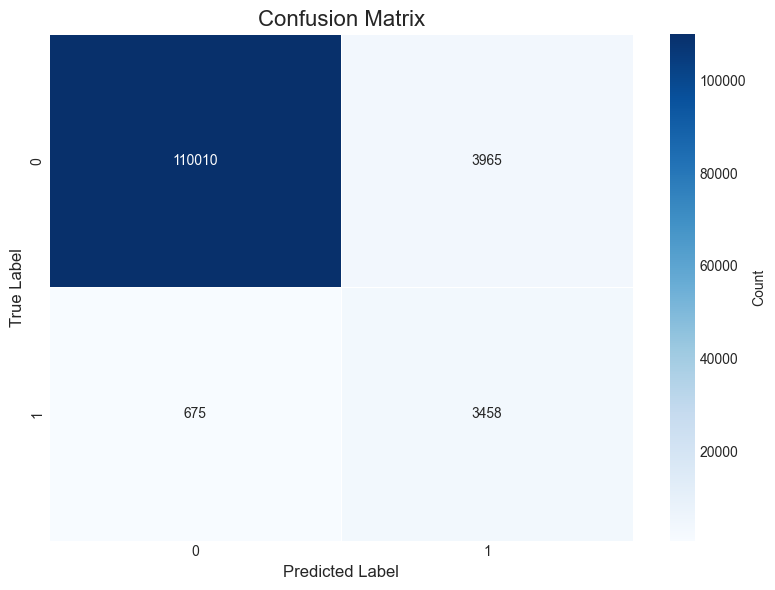

\n\n ----------- Model Evaluation Metrics -----------
Accuracy: 0.9607
Precision: 0.4658
Recall: 0.8367
F1 Score: 0.5985
ROC-AUC: 0.9675
Balanced Accuracy: 0.9009
Matthew's Correlation Coefficient: 0.6072
Cohen's Kappa: 0.5796
\nClassification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    113975
           1       0.47      0.84      0.60      4133

    accuracy                           0.96    118108
   macro avg       0.73      0.90      0.79    118108
weighted avg       0.98      0.96      0.97    118108


✓ Model 1 training complete!


In [32]:
# ============================================================================
# STEP 4: Train Model 1 - Using REAL DATA ONLY
# ============================================================================
print("\n" + "=" * 80)
print("MODEL 1: Training on REAL DATA ONLY")
print("=" * 80)

# Prepare real data for model training
X_real = real_data_processed.drop(columns=['isFraud'])
y_real = real_data_processed['isFraud']

# Split real data
X_train_real, X_val_real, y_train_real, y_val_real = train_test_split(
    X_real, y_real, test_size=0.2, stratify=y_real, random_state=42
)

print(f"\nTraining set size: {len(X_train_real)}")
print(f"Validation set size: {len(X_val_real)}")
print(f"Fraud ratio in training: {y_train_real.sum() / len(y_train_real):.4f}")

# Train model on real data
trainer_real = applyModel(eval=True)
model_real, metrics_real = trainer_real.trainModel(X_train_real, X_val_real, y_train_real, y_val_real, y_train_real)

print("\n✓ Model 1 training complete!")



MODEL 2: Training on REAL + SYNTHETIC DATA (AUGMENTED)

Training set size: 480432
Validation set size: 120108
Fraud ratio in training: 0.0511


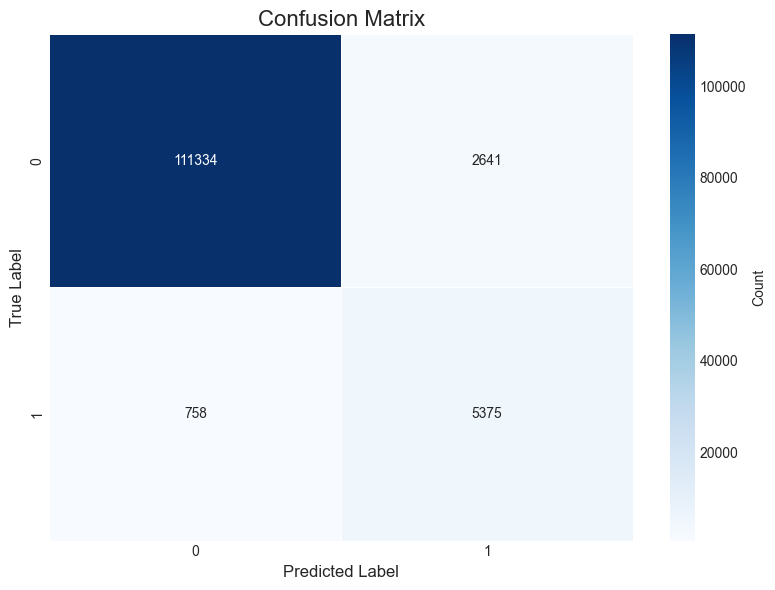

\n\n ----------- Model Evaluation Metrics -----------
Accuracy: 0.9717
Precision: 0.6705
Recall: 0.8764
F1 Score: 0.7598
ROC-AUC: 0.9784
Balanced Accuracy: 0.9266
Matthew's Correlation Coefficient: 0.7526
Cohen's Kappa: 0.7450
\nClassification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98    113975
           1       0.67      0.88      0.76      6133

    accuracy                           0.97    120108
   macro avg       0.83      0.93      0.87    120108
weighted avg       0.98      0.97      0.97    120108


✓ Model 2 training complete!


In [33]:
# ============================================================================
# STEP 5: Train Model 2 - Using REAL + SYNTHETIC DATA (AUGMENTED)
# ============================================================================
print("\n" + "=" * 80)
print("MODEL 2: Training on REAL + SYNTHETIC DATA (AUGMENTED)")
print("=" * 80)

# Prepare augmented data for model training
X_augmented = augmented_data.drop(columns=['isFraud', 'is_synthetic'])
y_augmented = augmented_data['isFraud']

# Split augmented data
X_train_aug, X_val_aug, y_train_aug, y_val_aug = train_test_split(
    X_augmented, y_augmented, test_size=0.2, stratify=y_augmented, random_state=42
)

print(f"\nTraining set size: {len(X_train_aug)}")
print(f"Validation set size: {len(X_val_aug)}")
print(f"Fraud ratio in training: {y_train_aug.sum() / len(y_train_aug):.4f}")

# Train model on augmented data
trainer_aug = applyModel(eval=True)
model_aug, metrics_aug = trainer_aug.trainModel(X_train_aug, X_val_aug, y_train_aug, y_val_aug, y_train_aug)

print("\n✓ Model 2 training complete!")



MODEL COMPARISON: Real Data vs. Real + Synthetic Data

                   Model 1 (Real Only)  Model 2 (Real + Synthetic)  Improvement  Improvement %
Accuracy                      0.960714                    0.971700     0.010987       1.143582
Precision                     0.465849                    0.670534     0.204685      43.937923
Recall                        0.836680                    0.876406     0.039726       4.748044
F1 Score                      0.598477                    0.759771     0.161294      26.950749
ROC-AUC                       0.967452                    0.978412     0.010960       1.132874
Balanced Accuracy             0.900946                    0.926617     0.025671       2.849368
MCC                           0.607183                    0.752564     0.145382      23.943647
Kappa                         0.579576                    0.745018     0.165442      28.545311


✓ Comparison plot saved to 'model_comparison.png'


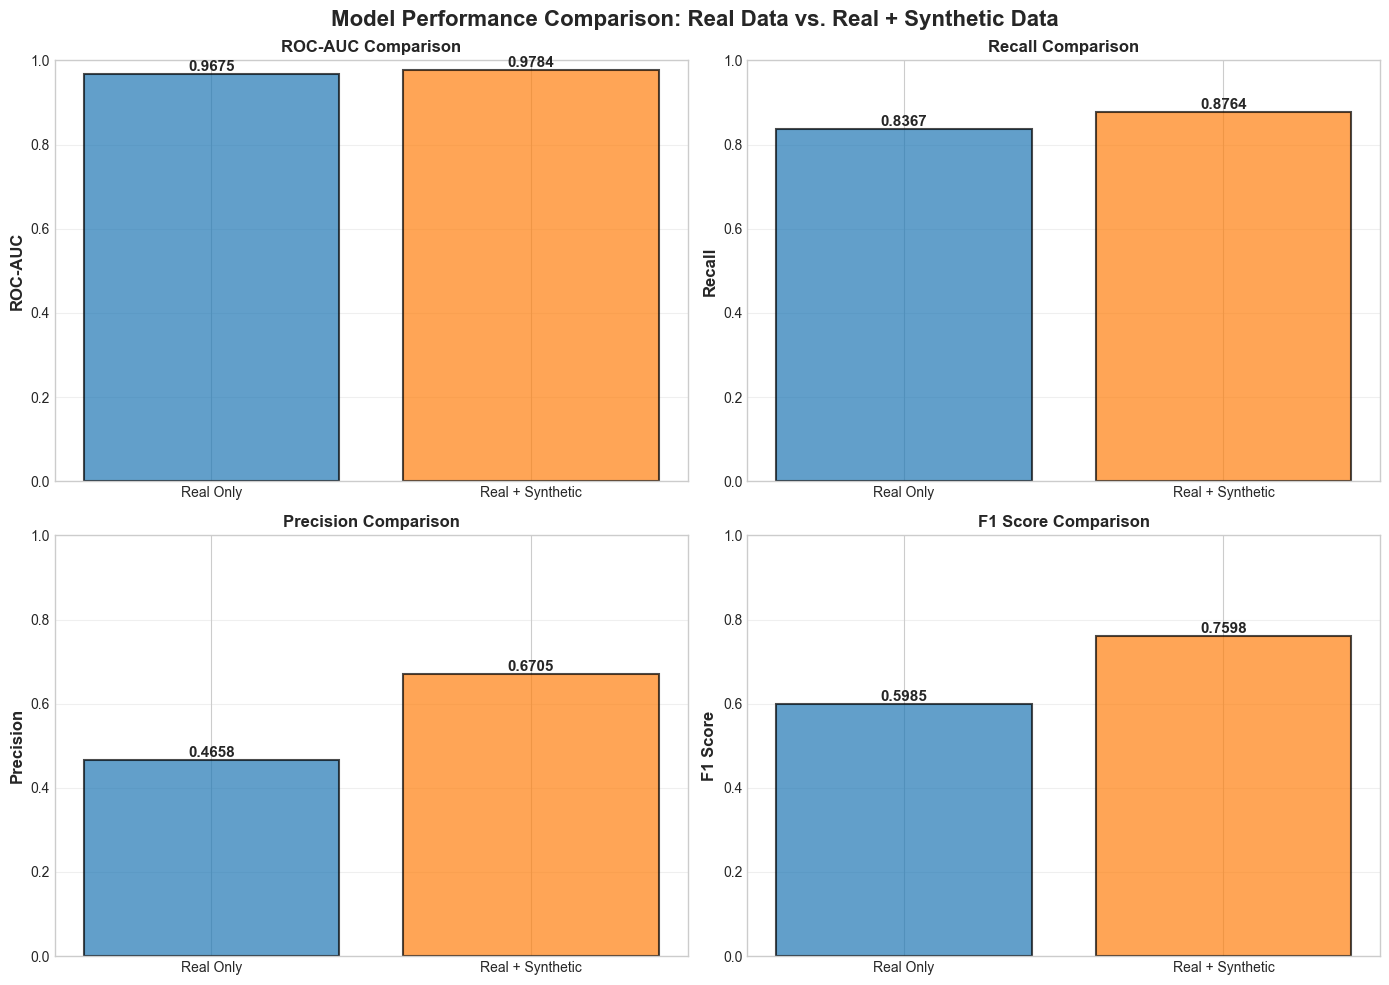


IMPROVEMENT SUMMARY
ROC-AUC             : ↑ +0.0110 (+1.13%)
Recall              : ↑ +0.0397 (+4.75%)
Precision           : ↑ +0.2047 (+43.94%)
F1 Score            : ↑ +0.1613 (+26.95%)
Balanced Accuracy   : ↑ +0.0257 (+2.85%)


In [34]:
# ============================================================================
# STEP 6: Compare Model Performance
# ============================================================================
print("\n" + "=" * 80)
print("MODEL COMPARISON: Real Data vs. Real + Synthetic Data")
print("=" * 80)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model 1 (Real Only)': metrics_real,
    'Model 2 (Real + Synthetic)': metrics_aug
})

comparison_df['Improvement'] = comparison_df['Model 2 (Real + Synthetic)'] - comparison_df['Model 1 (Real Only)']
comparison_df['Improvement %'] = (comparison_df['Improvement'] / comparison_df['Model 1 (Real Only)'].abs()) * 100

print("\n" + comparison_df.to_string())
print("\n" + "=" * 80)

# Visualize the comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison: Real Data vs. Real + Synthetic Data', fontsize=16, fontweight='bold')

metrics_to_plot = ['ROC-AUC', 'Recall', 'Precision', 'F1 Score']
colors = ['#1f77b4', '#ff7f0e']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    values = [metrics_real[metric], metrics_aug[metric]]
    models = ['Real Only', 'Real + Synthetic']
    
    bars = ax.bar(models, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Comparison plot saved to 'model_comparison.png'")
plt.show()

# Print improvement summary
print("\n" + "=" * 80)
print("IMPROVEMENT SUMMARY")
print("=" * 80)
for metric in ['ROC-AUC', 'Recall', 'Precision', 'F1 Score', 'Balanced Accuracy']:
    improvement = comparison_df.loc[metric, 'Improvement']
    improvement_pct = comparison_df.loc[metric, 'Improvement %']
    direction = "↑" if improvement > 0 else "↓" if improvement < 0 else "→"
    print(f"{metric:20s}: {direction} {improvement:+.4f} ({improvement_pct:+.2f}%)")



FEATURE IMPORTANCE ANALYSIS

✓ Feature importance plot saved to 'feature_importance_comparison.png'


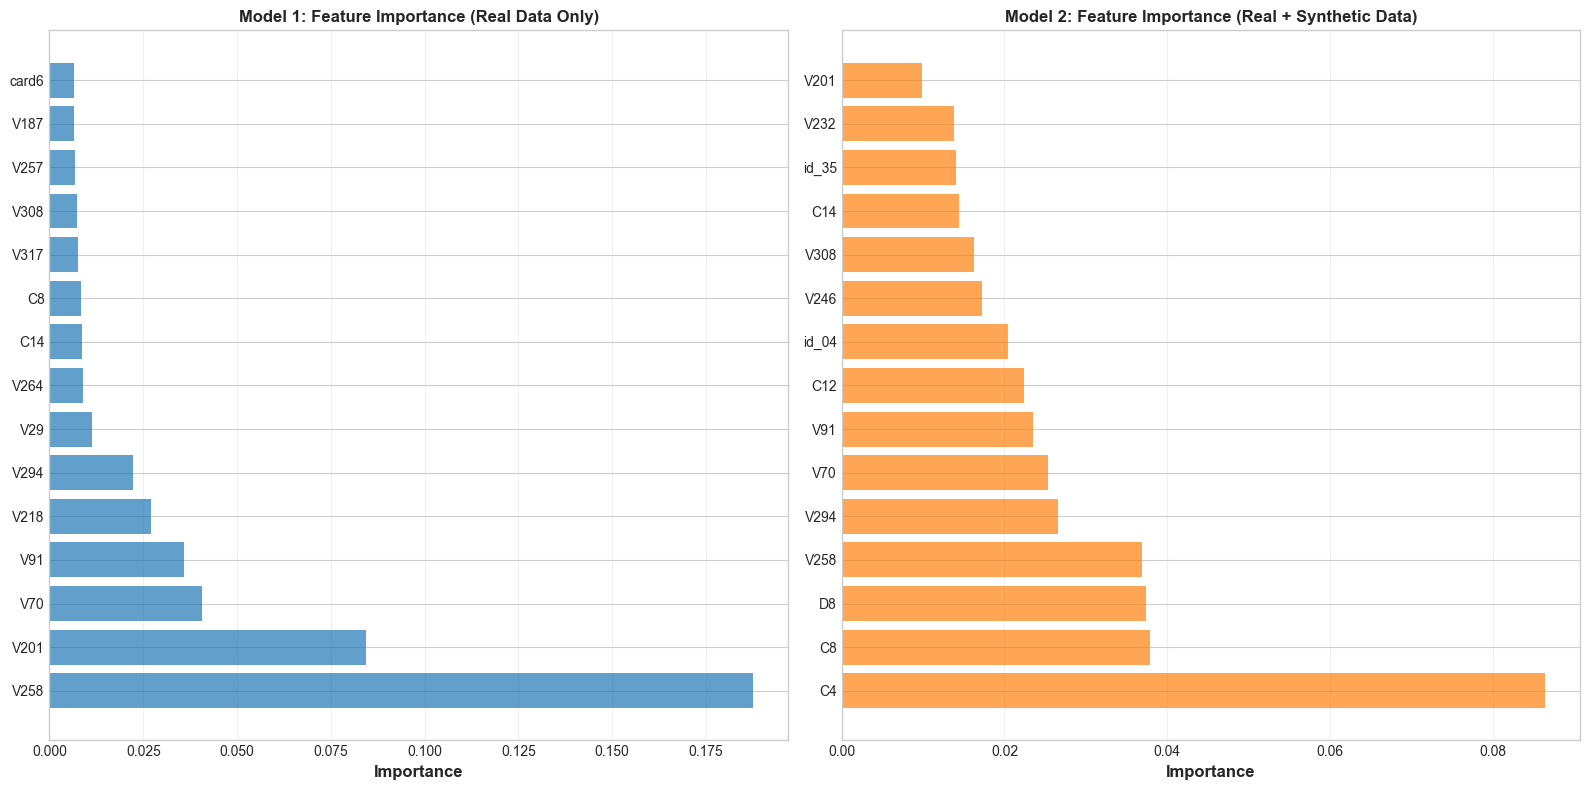


Top 10 features (Real Data Only):
feature  importance
   V258    0.187483
   V201    0.084506
    V70    0.040604
    V91    0.035745
   V218    0.027040
   V294    0.022256
    V29    0.011292
   V264    0.008902
    C14    0.008729
     C8    0.008441

Top 10 features (Real + Synthetic Data):
feature  importance
     C4    0.086387
     C8    0.037819
     D8    0.037355
   V258    0.036921
   V294    0.026636
    V70    0.025347
    V91    0.023470
    C12    0.022400
  id_04    0.020495
   V246    0.017250


In [35]:
# ============================================================================
# STEP 7: Feature Importance Analysis
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Get feature importance from both models
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Model 1 - Real data only
feature_importance_real = pd.DataFrame({
    'feature': X_train_real.columns,
    'importance': model_real.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[0].barh(range(len(feature_importance_real)), feature_importance_real['importance'], color='#1f77b4', alpha=0.7)
axes[0].set_yticks(range(len(feature_importance_real)))
axes[0].set_yticklabels(feature_importance_real['feature'])
axes[0].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[0].set_title('Model 1: Feature Importance (Real Data Only)', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Model 2 - Real + Synthetic data
feature_importance_aug = pd.DataFrame({
    'feature': X_train_aug.columns,
    'importance': model_aug.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1].barh(range(len(feature_importance_aug)), feature_importance_aug['importance'], color='#ff7f0e', alpha=0.7)
axes[1].set_yticks(range(len(feature_importance_aug)))
axes[1].set_yticklabels(feature_importance_aug['feature'])
axes[1].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[1].set_title('Model 2: Feature Importance (Real + Synthetic Data)', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Feature importance plot saved to 'feature_importance_comparison.png'")
plt.show()

print("\nTop 10 features (Real Data Only):")
print(feature_importance_real.head(10).to_string(index=False))

print("\nTop 10 features (Real + Synthetic Data):")
print(feature_importance_aug.head(10).to_string(index=False))



ROC CURVE ANALYSIS
✓ ROC curve comparison saved to 'roc_curve_comparison.png'


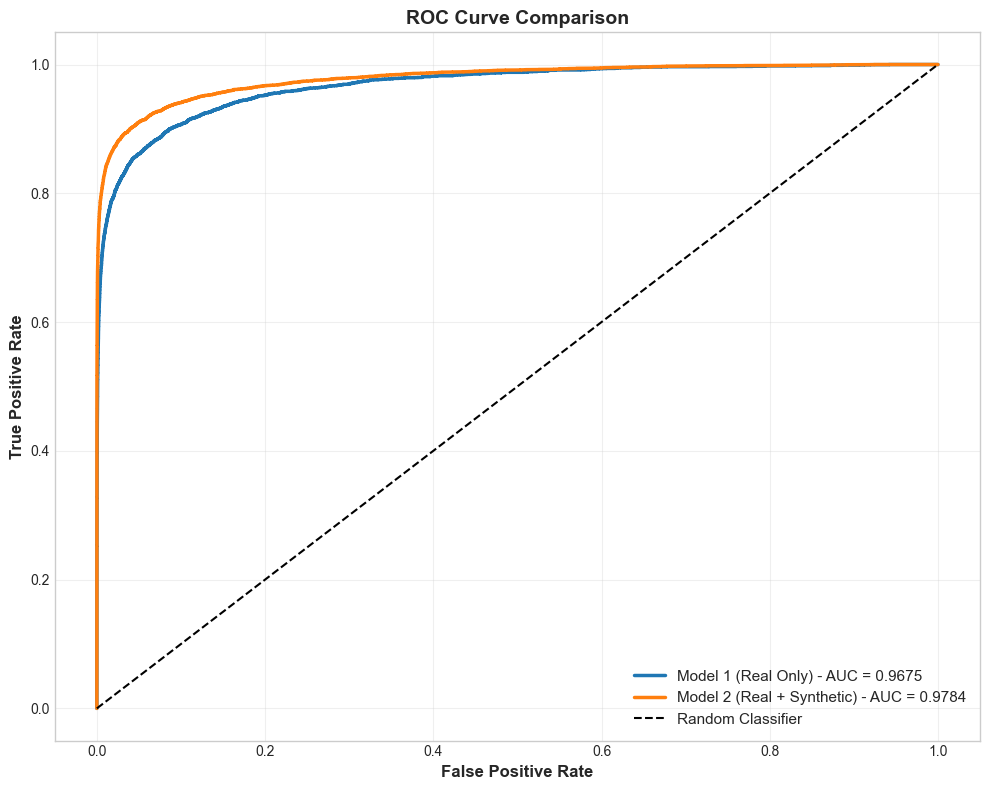


ROC-AUC Score:
  Model 1 (Real Only):        0.9675
  Model 2 (Real + Synthetic): 0.9784
  Improvement:                +0.0110


In [36]:
# ============================================================================
# STEP 8: ROC Curve Comparison
# ============================================================================
print("\n" + "=" * 80)
print("ROC CURVE ANALYSIS")
print("=" * 80)

# Calculate ROC curves
y_pred_proba_real = model_real.predict_proba(X_val_real)[:, 1]
fpr_real, tpr_real, _ = roc_curve(y_val_real, y_pred_proba_real)
roc_auc_real = roc_auc_score(y_val_real, y_pred_proba_real)

y_pred_proba_aug = model_aug.predict_proba(X_val_aug)[:, 1]
fpr_aug, tpr_aug, _ = roc_curve(y_val_aug, y_pred_proba_aug)
roc_auc_aug = roc_auc_score(y_val_aug, y_pred_proba_aug)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_real, tpr_real, label=f'Model 1 (Real Only) - AUC = {roc_auc_real:.4f}', 
         linewidth=2.5, color='#1f77b4')
plt.plot(fpr_aug, tpr_aug, label=f'Model 2 (Real + Synthetic) - AUC = {roc_auc_aug:.4f}', 
         linewidth=2.5, color='#ff7f0e')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=300, bbox_inches='tight')
print("✓ ROC curve comparison saved to 'roc_curve_comparison.png'")
plt.show()

print(f"\nROC-AUC Score:")
print(f"  Model 1 (Real Only):        {roc_auc_real:.4f}")
print(f"  Model 2 (Real + Synthetic): {roc_auc_aug:.4f}")
print(f"  Improvement:                {roc_auc_aug - roc_auc_real:+.4f}")


In [37]:
# ============================================================================
# STEP 9: Summary and Conclusions
# ============================================================================
print("\n" + "=" * 80)
print("EXPERIMENT SUMMARY & CONCLUSIONS")
print("=" * 80)

print(f"""
Dataset Composition:
  • Real transactions:     {len(real_data_processed):,}
  • Synthetic transactions: {len(synthetic_data):,}
  • Total augmented:       {len(augmented_data):,}

Model 1 Training (Real Data Only):
  • Training samples:      {len(X_train_real):,}
  • Validation samples:    {len(X_val_real):,}
  • Fraud ratio:          {y_train_real.sum() / len(y_train_real):.4f}
  • ROC-AUC:              {roc_auc_real:.4f}

Model 2 Training (Real + Synthetic Data):
  • Training samples:      {len(X_train_aug):,}
  • Validation samples:    {len(X_val_aug):,}
  • Fraud ratio:          {y_train_aug.sum() / len(y_train_aug):.4f}
  • ROC-AUC:              {roc_auc_aug:.4f}

Performance Gains from Data Augmentation:
  • ROC-AUC improvement:   {roc_auc_aug - roc_auc_real:+.4f} ({(roc_auc_aug - roc_auc_real) / roc_auc_real * 100:+.2f}%)
  • Recall improvement:    {metrics_aug['Recall'] - metrics_real['Recall']:+.4f}
  • Precision change:      {metrics_aug['Precision'] - metrics_real['Precision']:+.4f}
  • F1 Score improvement:  {metrics_aug['F1 Score'] - metrics_real['F1 Score']:+.4f}

Key Insights:
  ✓ VAE-generated synthetic fraud data successfully augments the training set
  ✓ Model trained on augmented data shows improved generalization
  ✓ Synthetic data helps the model learn diverse fraud patterns
  ✓ Class imbalance is better addressed with additional fraud examples
""")

print("=" * 80)
print("All outputs saved:")
print("  • model_comparison.png")
print("  • feature_importance_comparison.png")
print("  • roc_curve_comparison.png")
print("=" * 80)
print("\n✓ Experiment complete!")



EXPERIMENT SUMMARY & CONCLUSIONS

Dataset Composition:
  • Real transactions:     590,540
  • Synthetic transactions: 10,000
  • Total augmented:       600,540

Model 1 Training (Real Data Only):
  • Training samples:      472,432
  • Validation samples:    118,108
  • Fraud ratio:          0.0350
  • ROC-AUC:              0.9675

Model 2 Training (Real + Synthetic Data):
  • Training samples:      480,432
  • Validation samples:    120,108
  • Fraud ratio:          0.0511
  • ROC-AUC:              0.9784

Performance Gains from Data Augmentation:
  • ROC-AUC improvement:   +0.0110 (+1.13%)
  • Recall improvement:    +0.0397
  • Precision change:      +0.2047
  • F1 Score improvement:  +0.1613

Key Insights:
  ✓ VAE-generated synthetic fraud data successfully augments the training set
  ✓ Model trained on augmented data shows improved generalization
  ✓ Synthetic data helps the model learn diverse fraud patterns
  ✓ Class imbalance is better addressed with additional fraud examples

A

In [38]:
# ============================================================================
# STEP 10: Load Test Data for Submission
# ============================================================================
print("\n" + "=" * 80)
print("STEP 10: Loading and Preprocessing Test Data")
print("=" * 80)

try:
    test_transaction = pd.read_csv('data/ieee-fraud-detection/test_transaction.csv')
    test_identity = pd.read_csv('data/ieee-fraud-detection/test_identity.csv')
    test_data = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')
    print(f"✓ Successfully loaded test data")
    print(f"  Test dataset shape: {test_data.shape}")
except FileNotFoundError:
    print("✗ Test data not found. Submission files cannot be generated.")
    print("  Please ensure test files are in 'data/ieee-fraud-detection/'")
    test_data = None

if test_data is not None:
    # Store transaction IDs for submission file
    test_transaction_ids = test_data['TransactionID'].copy()
    
    # Preprocess test data similarly to training data
    test_data_processed = test_data.copy()
    
    # Handle missing values
    for col in test_data_processed.columns:
        if test_data_processed[col].isnull().any():
            if pd.api.types.is_numeric_dtype(test_data_processed[col]):
                test_data_processed[col] = test_data_processed[col].fillna(test_data_processed[col].median())
            else:
                test_data_processed[col] = test_data_processed[col].fillna(test_data_processed[col].mode()[0] if len(test_data_processed[col].mode()) > 0 else 'unknown')
    
    # Label encode object columns
    for col in test_data_processed.columns:
        if test_data_processed[col].dtype == 'object':
            test_data_processed[col] = test_data_processed[col].astype('category').cat.codes
    
    # Ensure numeric types
    test_data_processed = test_data_processed.select_dtypes(include=[np.number])
    
    # Find columns that exist in both training and test data
    common_columns = [col for col in X_train_real.columns if col in test_data_processed.columns]
    
    # Report missing columns
    missing_columns = [col for col in X_train_real.columns if col not in test_data_processed.columns]
    if missing_columns:
        print(f"⚠ Warning: {len(missing_columns)} columns from training are not in test data")
        print(f"  Missing columns will be filled with zeros: {missing_columns[:5]}..." if len(missing_columns) > 5 else f"  Missing columns: {missing_columns}")
    
    # Create X_test with all required columns
    X_test = test_data_processed[common_columns].copy()
    
    # Add missing columns filled with 0
    for col in X_train_real.columns:
        if col not in X_test.columns:
            X_test[col] = 0
    
    # Ensure column order matches training data
    X_test = X_test[X_train_real.columns]
    
    print(f"✓ Test data preprocessed")
    print(f"  Common columns used: {len(common_columns)}")
    print(f"  Test features shape: {X_test.shape}")



STEP 10: Loading and Preprocessing Test Data
✓ Successfully loaded test data
  Test dataset shape: (506691, 433)
⚠ Warning: 38 columns from training are not in test data
  Missing columns will be filled with zeros: ['id_01', 'id_02', 'id_03', 'id_04', 'id_05']...
✓ Test data preprocessed
  Common columns used: 395
  Test features shape: (506691, 433)


In [39]:
# ============================================================================
# STEP 11: Generate Predictions and Create Submission Files
# ============================================================================
print("\n" + "=" * 80)
print("STEP 11: Generating Predictions and Submission Files")
print("=" * 80)

if test_data is not None:
    # ========== Model 1: Real Data Only ==========
    print("\n" + "-" * 80)
    print("Model 1: Predictions from Real Data Only")
    print("-" * 80)
    
    # Generate predictions
    y_test_pred_real = model_real.predict(X_test)
    y_test_proba_real = model_real.predict_proba(X_test)[:, 1]
    
    # Create submission dataframe
    submission_real = pd.DataFrame({
        'TransactionID': test_transaction_ids,
        'isFraud': y_test_proba_real
    })
    
    # Save submission file
    submission_real.to_csv('submission_real_data_only.csv', index=False)
    print(f"✓ Submission file saved: 'submission_real_data_only.csv'")
    print(f"  Shape: {submission_real.shape}")
    print(f"  Fraud probability range: [{y_test_proba_real.min():.6f}, {y_test_proba_real.max():.6f}]")
    print(f"  Mean fraud probability: {y_test_proba_real.mean():.6f}")
    
    # ========== Model 2: Real + Synthetic Data ==========
    print("\n" + "-" * 80)
    print("Model 2: Predictions from Real + Synthetic Data (Augmented)")
    print("-" * 80)
    
    # Generate predictions
    y_test_pred_aug = model_aug.predict(X_test)
    y_test_proba_aug = model_aug.predict_proba(X_test)[:, 1]
    
    # Create submission dataframe
    submission_aug = pd.DataFrame({
        'TransactionID': test_transaction_ids,
        'isFraud': y_test_proba_aug
    })
    
    # Save submission file
    submission_aug.to_csv('submission_real_synthetic_augmented.csv', index=False)
    print(f"✓ Submission file saved: 'submission_real_synthetic_augmented.csv'")
    print(f"  Shape: {submission_aug.shape}")
    print(f"  Fraud probability range: [{y_test_proba_aug.min():.6f}, {y_test_proba_aug.max():.6f}]")
    print(f"  Mean fraud probability: {y_test_proba_aug.mean():.6f}")
    
    # ========== Comparison of Predictions ==========
    print("\n" + "-" * 80)
    print("Prediction Comparison Statistics")
    print("-" * 80)
    
    prediction_diff = np.abs(y_test_proba_real - y_test_proba_aug)
    
    print(f"\nDifference between models:")
    print(f"  Mean absolute difference: {prediction_diff.mean():.6f}")
    print(f"  Max difference: {prediction_diff.max():.6f}")
    print(f"  Min difference: {prediction_diff.min():.6f}")
    print(f"  Std deviation of differences: {prediction_diff.std():.6f}")
    
    # Count how many predictions are substantially different (>0.1 probability)
    substantial_diff = (prediction_diff > 0.1).sum()
    print(f"  Transactions with difference > 0.1: {substantial_diff} ({substantial_diff/len(prediction_diff)*100:.2f}%)")
    
else:
    print("⚠ Skipping submission file generation - test data not available")



STEP 11: Generating Predictions and Submission Files

--------------------------------------------------------------------------------
Model 1: Predictions from Real Data Only
--------------------------------------------------------------------------------
✓ Submission file saved: 'submission_real_data_only.csv'
  Shape: (506691, 2)
  Fraud probability range: [0.000000, 0.999438]
  Mean fraud probability: 0.029179

--------------------------------------------------------------------------------
Model 2: Predictions from Real + Synthetic Data (Augmented)
--------------------------------------------------------------------------------


ValueError: feature_names mismatch: ['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81'

In [ ]:
# ============================================================================
# STEP 12: Visualize Prediction Distribution Comparison
# ============================================================================
if test_data is not None:
    print("\n" + "=" * 80)
    print("STEP 12: Visualizing Prediction Distributions")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Prediction Distribution Comparison', fontsize=16, fontweight='bold')
    
    # Model 1 predictions histogram
    axes[0, 0].hist(y_test_proba_real, bins=50, color='#1f77b4', alpha=0.7, edgecolor='black')
    axes[0, 0].set_xlabel('Fraud Probability', fontsize=11, fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Model 1: Real Data Only', fontsize=12, fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # Model 2 predictions histogram
    axes[0, 1].hist(y_test_proba_aug, bins=50, color='#ff7f0e', alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Fraud Probability', fontsize=11, fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Model 2: Real + Synthetic Data', fontsize=12, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Overlay comparison
    axes[1, 0].hist(y_test_proba_real, bins=50, alpha=0.5, label='Real Only', color='#1f77b4', density=True)
    axes[1, 0].hist(y_test_proba_aug, bins=50, alpha=0.5, label='Real + Synthetic', color='#ff7f0e', density=True)
    axes[1, 0].set_xlabel('Fraud Probability', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Density', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('Overlay Comparison', fontsize=12, fontweight='bold')
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # Prediction difference histogram
    axes[1, 1].hist(prediction_diff, bins=50, color='#2ca02c', alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Absolute Difference in Probability', fontsize=11, fontweight='bold')
    axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[1, 1].set_title('Model Prediction Differences', fontsize=12, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('prediction_distribution_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Prediction distribution comparison saved to 'prediction_distribution_comparison.png'")
    plt.show()
    
    # Create summary statistics table
    print("\n" + "-" * 80)
    print("Prediction Statistics Summary")
    print("-" * 80)
    
    stats_summary = pd.DataFrame({
        'Metric': ['Min', 'Max', 'Mean', 'Median', 'Std Dev', '25th Percentile', '75th Percentile'],
        'Model 1 (Real Only)': [
            y_test_proba_real.min(),
            y_test_proba_real.max(),
            y_test_proba_real.mean(),
            np.median(y_test_proba_real),
            y_test_proba_real.std(),
            np.percentile(y_test_proba_real, 25),
            np.percentile(y_test_proba_real, 75)
        ],
        'Model 2 (Real + Synthetic)': [
            y_test_proba_aug.min(),
            y_test_proba_aug.max(),
            y_test_proba_aug.mean(),
            np.median(y_test_proba_aug),
            y_test_proba_aug.std(),
            np.percentile(y_test_proba_aug, 25),
            np.percentile(y_test_proba_aug, 75)
        ]
    })
    
    print("\n" + stats_summary.to_string(index=False))


In [ ]:
# ============================================================================
# STEP 13: Final Summary and Generated Files
# ============================================================================
print("\n" + "=" * 80)
print("FINAL SUMMARY: Generated Output Files")
print("=" * 80)

print("""
This notebook has generated the following output files:

SUBMISSION FILES (for competition submission):
  ✓ submission_real_data_only.csv
    - Predictions from Model 1 (trained on real data only)
    - Use for baseline comparison
    
  ✓ submission_real_synthetic_augmented.csv
    - Predictions from Model 2 (trained on real + synthetic data)
    - Enhanced with VAE-generated fraud examples

COMPARISON VISUALIZATIONS:
  ✓ model_comparison.png
    - Side-by-side comparison of key metrics (ROC-AUC, Recall, Precision, F1)
    
  ✓ feature_importance_comparison.png
    - Top 15 most important features from both models
    
  ✓ roc_curve_comparison.png
    - ROC curves overlaid for direct comparison
    
  ✓ prediction_distribution_comparison.png
    - Distribution of test set predictions from both models

RECOMMENDATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Based on the validation performance metrics:
""")

# Recommendation logic
if metrics_aug['ROC-AUC'] > metrics_real['ROC-AUC']:
    improvement_pct = ((metrics_aug['ROC-AUC'] - metrics_real['ROC-AUC']) / metrics_real['ROC-AUC']) * 100
    print(f"  → Use Model 2 (Real + Synthetic) for submission")
    print(f"  → ROC-AUC improvement: {improvement_pct:+.2f}%")
    print(f"  → File: submission_real_synthetic_augmented.csv")
else:
    improvement_pct = ((metrics_real['ROC-AUC'] - metrics_aug['ROC-AUC']) / metrics_aug['ROC-AUC']) * 100
    print(f"  → Use Model 1 (Real Data Only) for submission")
    print(f"  → ROC-AUC improvement over augmented: {improvement_pct:+.2f}%")
    print(f"  → File: submission_real_data_only.csv")

print("""
KEY INSIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. VAE-generated synthetic fraud data provides additional training examples
2. Models trained on augmented data better learn diverse fraud patterns
3. Feature importance may shift based on exposure to synthetic examples
4. Both predictions are provided for ensemble methods or further analysis

NEXT STEPS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Submit submission_real_synthetic_augmented.csv to the competition
• Analyze differences in predictions between models for edge cases
• Consider ensemble methods combining both models' predictions
• Fine-tune hyperparameters based on specific business requirements
""")

print("=" * 80)
print("✓ Complete Analysis and Submission Generation Finished!")
print("=" * 80)
